In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import mlflow
import mlflow.sklearn
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

# === Load dataset ===
WIN_PATH_1 = "/Users/aleksandar.stojanovic/Downloads/ai_system/ml_scripts/data/processed/win_model_data.parquet"
WIN_PATH_2 = "/Users/aleksandar.stojanovic/Downloads/ai_system/ml_scripts/data/processed/win_model_data_draw.parquet"

df1 = pd.read_parquet(WIN_PATH_1)
df2 = pd.read_parquet(WIN_PATH_2)

df = pd.concat([df1, df2], ignore_index=True)
X = np.vstack(df["features"].values)
y = df["target"].values  # 0 = WIN_X, 1 = WIN_O, 2 = DRAW


LABEL_MAP = {0: "WIN_X", 1: "WIN_O", 2: "DRAW"}

# === Probabilities Helper ===

def log_probabilities(y_proba, run_name, max_rows=10):
    df_probs = pd.DataFrame(y_proba, columns=["P(WIN_X)", "P(WIN_O)", "P(DRAW)"])
    df_probs["predicted_label"] = df_probs.apply(
        lambda row: LABEL_MAP[int(np.argmax(row.values))], axis=1
    )
    sample = df_probs.head(max_rows)

    print(f"\n{run_name} win probabilities (sample):")
    for _, row in sample.iterrows():
        probs = [row["P(WIN_X)"], row["P(WIN_O)"], row["P(DRAW)"]]
        print(f"[P(WIN_X), P(WIN_O), P(DRAW)] = {probs} -> {row['predicted_label']}")

    # Log a sample for inspection in MLflow
    mlflow.log_table(sample, f"probabilities/{run_name}_proba_sample.json")

# === Train/Test split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# === Confusion Matrix Helper ===
def log_confusion_matrix(cm, run_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {run_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        fig.savefig(tmp.name)
        mlflow.log_artifact(tmp.name, artifact_path="confusion_matrices")

2025/12/23 16:59:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/23 16:59:03 INFO mlflow.store.db.utils: Updating database tables
2025/12/23 16:59:03 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/23 16:59:03 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/23 16:59:03 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/23 16:59:03 INFO alembic.runtime.migration: Will assume non-transactional DDL.



logistic_regression_win_model win probabilities (sample):
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.28314615170782487, 0.6534937761743274, 0.06336007211784772] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.607531783579539, 0.3703735707606425, 0.02209464565981854] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.2421460674543652, 0.7393735176989726, 0.018480414846661977] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.607531783579539, 0.3703735707606425, 0.02209464565981854] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.5035553157926456, 0.4389822457604797, 0.057462438446874785] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.607531783579539, 0.3703735707606425, 0.02209464565981854] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.2930105298457686, 0.6470345243143351, 0.05995494583989635] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.607531783579539, 0.3703735707606425, 0.02209464565981854] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6211770405366963, 0.3354671165361454, 0.043355842927158245] -> WIN_X
[P(WIN_X), P(W

2025/12/23 16:59:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/23 16:59:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/23 16:59:06 INFO mlflow.store.db.utils: Updating database tables
2025/12/23 16:59:06 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/23 16:59:06 INFO alembic.runtime.migration: Will assume non-transactional DDL.
Registered model 'win_model_logreg' already exists. Creating a new version of this model...
Created version '3' of model 'win_model_logreg'.


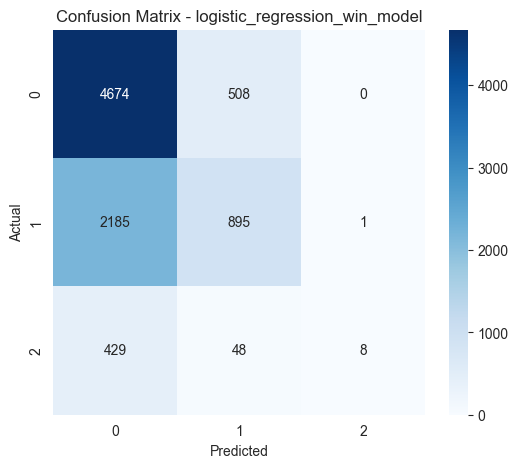

In [2]:
with mlflow.start_run(run_name="logistic_regression_win_model"):
    start_time = time.time()
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        y_pred_proba = np.argmax(y_proba, axis=1)
        log_probabilities(y_proba, "logistic_regression_win_model")
    else:
        print("\nlogistic_regression_win_model does not support predict_proba().")
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log metrics ===
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # Per-class metrics
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    # Macro/weighted
    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # Confusion matrix
    log_confusion_matrix(cm, "logistic_regression_win_model")

    # Log model
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_logreg")


2025/12/23 16:59:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



random_forest_win_model win probabilities (sample):
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.08732788859007716, 0.9126721114099229, 0.0] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6114810361444539, 0.3489630674048756, 0.03955589645067063] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.03184010877912209, 0.9355975586203286, 0.032562332600549214] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6114810361444539, 0.3489630674048756, 0.03955589645067063] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.030845785028738512, 0.9691542149712614, 0.0] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6114810361444539, 0.3489630674048756, 0.03955589645067063] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.0, 1.0, 0.0] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6114810361444539, 0.3489630674048756, 0.03955589645067063] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.4513679448476256, 0.4399666703778433, 0.10866538477453105] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.4792313209254586, 0.51663373876058, 0.00413494031396119] -

Registered model 'win_model_random_forest' already exists. Creating a new version of this model...
Created version '3' of model 'win_model_random_forest'.


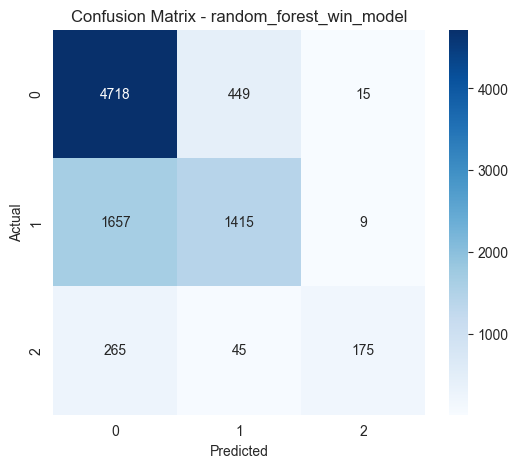

In [3]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="random_forest_win_model"):
    start_time = time.time()
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        y_pred_proba = np.argmax(y_proba, axis=1)
        log_probabilities(y_proba, "random_forest_win_model")
    else:
        print("\nrandom_forest_win_model does not support predict_proba().")
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log class-level metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Confusion Matrix ===
    log_confusion_matrix(cm, "random_forest_win_model")

    # === Log model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_random_forest")


/Users/aleksandar.stojanovic/Downloads/ai_system/.venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:59:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2025/12/23 16:59:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



xgboost_win_model win probabilities (sample):
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.10900422185659409, 0.8882083892822266, 0.002787370700389147] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6096963882446289, 0.349643349647522, 0.04066024720668793] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.10784082114696503, 0.8879165649414062, 0.004242634866386652] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6096963882446289, 0.349643349647522, 0.04066024720668793] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.0887029618024826, 0.9103740453720093, 0.0009229746647179127] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6096963882446289, 0.349643349647522, 0.04066024720668793] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.023787351325154305, 0.9745431542396545, 0.0016694788355380297] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6096963882446289, 0.349643349647522, 0.04066024720668793] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.5257886052131653, 0.3823740482330322, 0.09183736890554428] -> WIN_X
[P(WIN_X), P(WIN_O),

Registered model 'win_model_xgboost' already exists. Creating a new version of this model...
Created version '3' of model 'win_model_xgboost'.


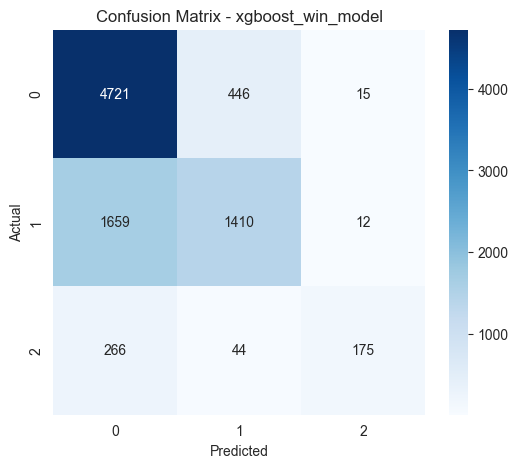

In [4]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="xgboost_win_model"):
    start_time = time.time()
    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        y_pred_proba = np.argmax(y_proba, axis=1)
        log_probabilities(y_proba, "xgboost_win_model")
    else:
        print("\nxgboost_win_model does not support predict_proba().")
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Log confusion matrix ===
    log_confusion_matrix(cm, "xgboost_win_model")

    # === Log model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_xgboost")


2025/12/23 16:59:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



mlp_64x64_win_model win probabilities (sample):
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.11710384509420965, 0.8828717643759683, 2.4390529822136995e-05] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6061828464545859, 0.35566196939220523, 0.03815518415320896] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.06432725194322621, 0.9125245832864263, 0.023148164770347517] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6061828464545859, 0.35566196939220523, 0.03815518415320896] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.020920176056229776, 0.9790754536062136, 4.370337556674769e-06] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6061828464545859, 0.35566196939220523, 0.03815518415320896] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.013887515017797478, 0.9826423511316663, 0.0034701338505361166] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6061828464545859, 0.35566196939220523, 0.03815518415320896] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.4528575636797728, 0.4236924607030257, 0.12344997561720156] -> WIN_X
[P(WIN

Registered model 'win_model_mlp_64x64' already exists. Creating a new version of this model...
Created version '3' of model 'win_model_mlp_64x64'.


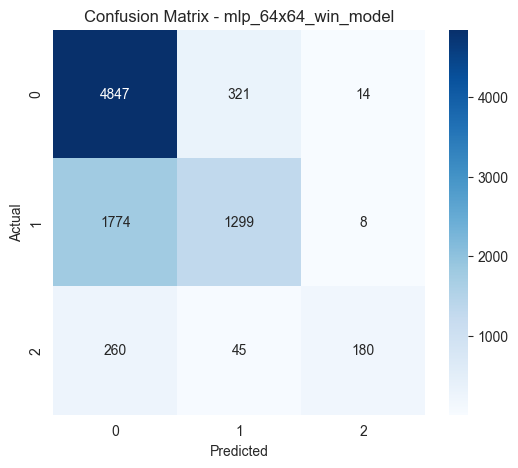

In [5]:
from sklearn.neural_network import MLPClassifier

with mlflow.start_run(run_name="mlp_64x64_win_model"):
    start_time = time.time()
    model = MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        y_pred_proba = np.argmax(y_proba, axis=1)
        log_probabilities(y_proba, "mlp_64x64_win_model")
    else:
        print("\nmlp_64x64_win_model does not support predict_proba().")
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "MLPClassifier_64x64")
    mlflow.log_param("layers", "64x64")
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log class metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Log confusion matrix ===
    log_confusion_matrix(cm, "mlp_64x64_win_model")

    # === Save model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_mlp_64x64")


2025/12/23 17:00:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



mlp_128x128_win_model win probabilities (sample):
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.11279318896798861, 0.8870739096559045, 0.00013290137610690682] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6211920057642429, 0.34190176627064484, 0.03690622796511237] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.037922794550436595, 0.9418656282674613, 0.020211577182102092] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6211920057642429, 0.34190176627064484, 0.03690622796511237] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.0333124457029383, 0.966634093081217, 5.346121584474886e-05] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6211920057642429, 0.34190176627064484, 0.03690622796511237] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.012260377769290218, 0.987492202735328, 0.0002474194953818356] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6211920057642429, 0.34190176627064484, 0.03690622796511237] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.48258905414538705, 0.4301889477861785, 0.08722199806843442] -> WIN_X
[P(WIN

Registered model 'win_model_mlp_128x128' already exists. Creating a new version of this model...
Created version '3' of model 'win_model_mlp_128x128'.


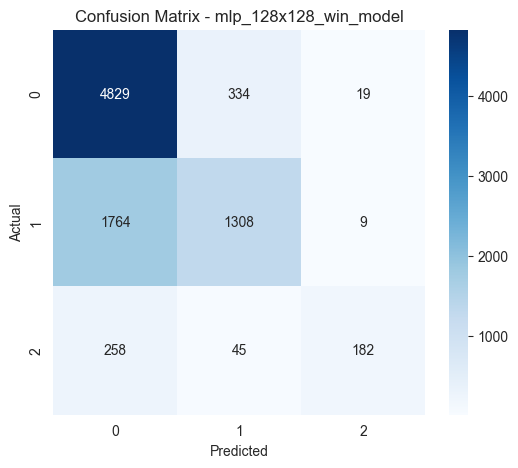

In [6]:
with mlflow.start_run(run_name="mlp_128x128_win_model"):
    start_time = time.time()
    model = MLPClassifier(
        hidden_layer_sizes=(128, 128),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        y_pred_proba = np.argmax(y_proba, axis=1)
        log_probabilities(y_proba, "mlp_128x128_win_model")
    else:
        print("\nmlp_128x128_win_model does not support predict_proba().")
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "MLPClassifier_128x128")
    mlflow.log_param("layers", "128x128")
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log per-class metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Log confusion matrix ===
    log_confusion_matrix(cm, "mlp_128x128_win_model")

    # === Log model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_mlp_128x128")


2025/12/23 17:00:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



catboost_win_model win probabilities (sample):
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.1681470390160062, 0.8284447325782593, 0.003408228405734413] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6102337222069509, 0.3503224271632403, 0.0394438506298089] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.18636703134331278, 0.8036999683648611, 0.009933000291826125] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6102337222069509, 0.3503224271632403, 0.0394438506298089] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.1349185997378232, 0.8589053625407499, 0.006176037721426865] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6102337222069509, 0.3503224271632403, 0.0394438506298089] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.029616672936139024, 0.96770467848011, 0.0026786485837510254] -> WIN_O
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.6102337222069509, 0.3503224271632403, 0.0394438506298089] -> WIN_X
[P(WIN_X), P(WIN_O), P(DRAW)] = [0.5076004584511956, 0.40473482756836976, 0.08766471398043463] -> WIN_X
[P(WIN_X), P(WIN_O), P

Registered model 'win_model_catboost' already exists. Creating a new version of this model...
Created version '3' of model 'win_model_catboost'.


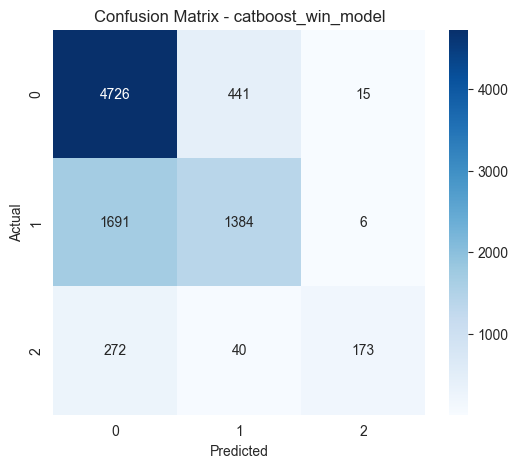

In [7]:
from catboost import CatBoostClassifier

with mlflow.start_run(run_name="catboost_win_model"):
    start_time = time.time()
    model = CatBoostClassifier(
        iterations=100,
        depth=6,
        learning_rate=0.1,
        verbose=0,
        random_seed=42
    )
    model.fit(X_train, y_train)
    end_time = time.time()

    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)
        y_pred_proba = np.argmax(y_proba, axis=1)
        log_probabilities(y_proba, "catboost_win_model")
    else:
        print("\ncatboost_win_model does not support predict_proba().")
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)
    cm = confusion_matrix(y_val, y_pred)

    # === Log parameters ===
    mlflow.log_param("model", "CatBoost")
    mlflow.log_param("iterations", 100)
    mlflow.log_param("depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end_time - start_time)

    # === Log per-class metrics ===
    for label in report.keys():
        if label in ["0", "1", "2"]:
            prefix = f"class_{label}_"
            for metric in ["precision", "recall", "f1-score", "support"]:
                mlflow.log_metric(prefix + metric, report[label][metric])

    for avg in ["macro avg", "weighted avg"]:
        prefix = avg.replace(" ", "_") + "_"
        for metric in ["precision", "recall", "f1-score", "support"]:
            mlflow.log_metric(prefix + metric, report[avg][metric])

    # === Log confusion matrix ===
    log_confusion_matrix(cm, "catboost_win_model")

    # === Log model ===
    mlflow.sklearn.log_model(model, artifact_path="model", registered_model_name="win_model_catboost")
